**Mashalov Rasulbek, OSTC2U, Machine Learning, HomeWork 6, 17th March, 2026**

In [54]:
import os
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
import warnings
import matplotlib.pyplot as plt
import math
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

**EXERCISE 1**

In [55]:
#loading dataset
file_path = "/content/drive/MyDrive/mL_unideb/Human_Activity_Recognition_Using_Smartphones_Data.csv"

data = pd.read_csv(file_path, on_bad_lines='skip', engine='python')

#creating X (features) and y (target)
X = data.drop("Activity", axis=1)
y = data["Activity"]

#initializing LabelEncoder
label_encoder = LabelEncoder()

#fitting&transforming the 'Activity' column
y_encoded = label_encoder.fit_transform(y)

#creating training and test splits using the encoded labels
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=2021)

print("[INFO] Human Activity dataset loaded and labels encoded!")
print(f"[INFO] Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

[INFO] Human Activity dataset loaded and labels encoded!
[INFO] Training set size: 7871, Test set size: 1968


In [56]:
#initiating Gaussian Naive Bayes training
X_train_numeric = X_train.apply(pd.to_numeric, errors='coerce').copy()
X_test_numeric = X_test.apply(pd.to_numeric, errors='coerce').copy()

#handling NaN values
X_train_numeric = X_train_numeric.fillna(X_train_numeric.mean())
X_test_numeric = X_test_numeric.fillna(X_test_numeric.mean())

#initializing Gaussian model
gnb_model = GaussianNB()

#fitting the model to the training split using the numeric data
gnb_model.fit(X_train_numeric, y_train)

#getting predictions on the test set using the numeric data
y_pred_gnb = gnb_model.predict(X_test_numeric)

print("[INFO] Model trained and predictions generated")

[INFO] Model trained and predictions generated


[INFO] Gaussian NB Accuracy: 70.58%


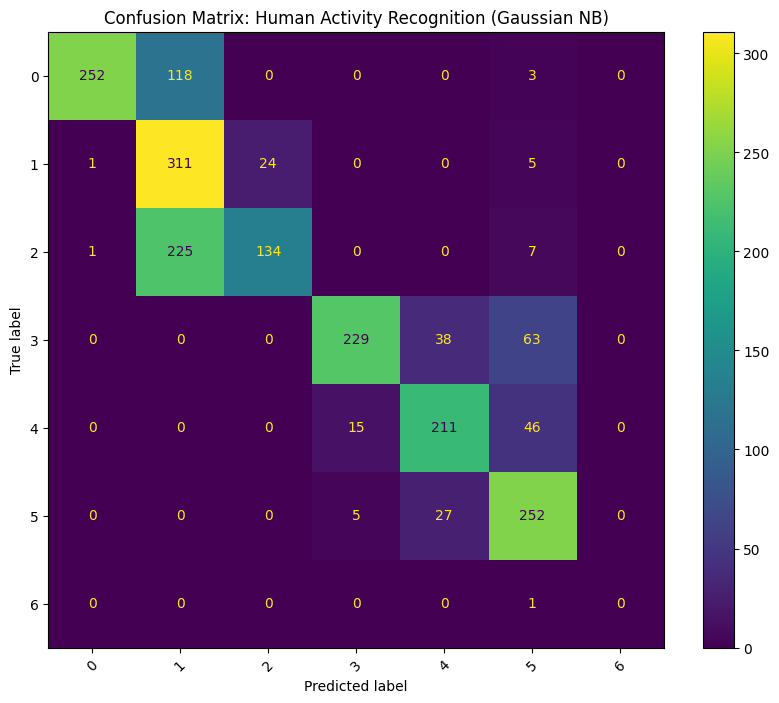

In [57]:
#calculating&printing the accuracy score
accuracy = accuracy_score(y_test, y_pred_gnb)
print(f"[INFO] Gaussian NB Accuracy: {accuracy * 100:.2f}%")

#plotting the colored confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gnb, ax=ax)

#titling&labeling
plt.title("Confusion Matrix: Human Activity Recognition (Gaussian NB)")
plt.xticks(rotation=45)
plt.show()

**EXERCISE 2**

In [58]:
file_path_spam = "/content/drive/MyDrive/mL_unideb/spam.csv"

#function to load the full dateset, bypassing panda's rules
def load_spam_data(path):
    data = []

    with open(path, 'r', encoding='latin-1') as file:
        lines = file.readlines()

    for line in lines[1:]: #skipping the header row
        line = line.strip()
        if not line:
            continue

        parts = line.split(',', 1)

        if len(parts) == 2:
            label = parts[0].strip()
            text = parts[1].strip()

            #cleaning up trailing commas which Kaggle created
            text = text.rstrip(',')

            #mapping 'ham' to 0 and 'spam' to 1
            if label == 'ham':
                data.append([0, text])
            elif label == 'spam':
                data.append([1, text])

    #converting data into DataFrame
    return pd.DataFrame(data, columns=['label', 'text'])

df_spam = load_spam_data(file_path_spam)
print(f"[INFO] Loaded {len(df_spam)} records from spam.csv.")

[INFO] Loaded 4163 records from spam.csv.


[INFO] Initiating Naive Bayes training records...
[INFO] Spam Model Accuracy: 98.92%


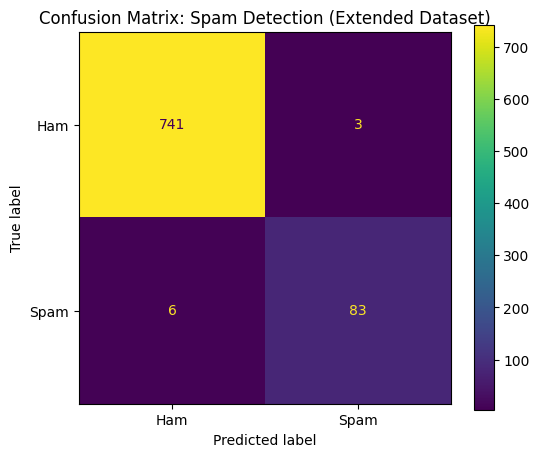

In [59]:
#separating features and target
X_text = df_spam['text']
y_spam = df_spam['label']

#vectorizing text data (words -> matrix of token counts)
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X_text)

#creating Train&Test splits
X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(X_vectorized, y_spam, test_size=0.2, random_state=2021)

print("[INFO] Initiating Naive Bayes training records...")

#training the Naive Bayes model
spam_model = MultinomialNB()
spam_model.fit(X_train_sp, y_train_sp)

#getting predictions on the test set
y_pred_sp = spam_model.predict(X_test_sp)

#evaluating efficiency
acc_sp = accuracy_score(y_test_sp, y_pred_sp)
print(f"[INFO] Spam Model Accuracy: {acc_sp * 100:.2f}%")

#confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_sp, y_pred_sp, display_labels=['Ham', 'Spam'], ax=ax)
plt.title("Confusion Matrix: Spam Detection (Extended Dataset)")
plt.show()